# Visualisasi Persebaran Data Gambar


,kelas,jumlah_gambar
0,Toraja,980
1,balinese,776
2,Papua,613
3,minangkabau,563
4,javanese,249
5,Banten,165
6,Nusa Tenggara (sasak),161
7,Maluku,119
8,batak,95
9,dayak,69


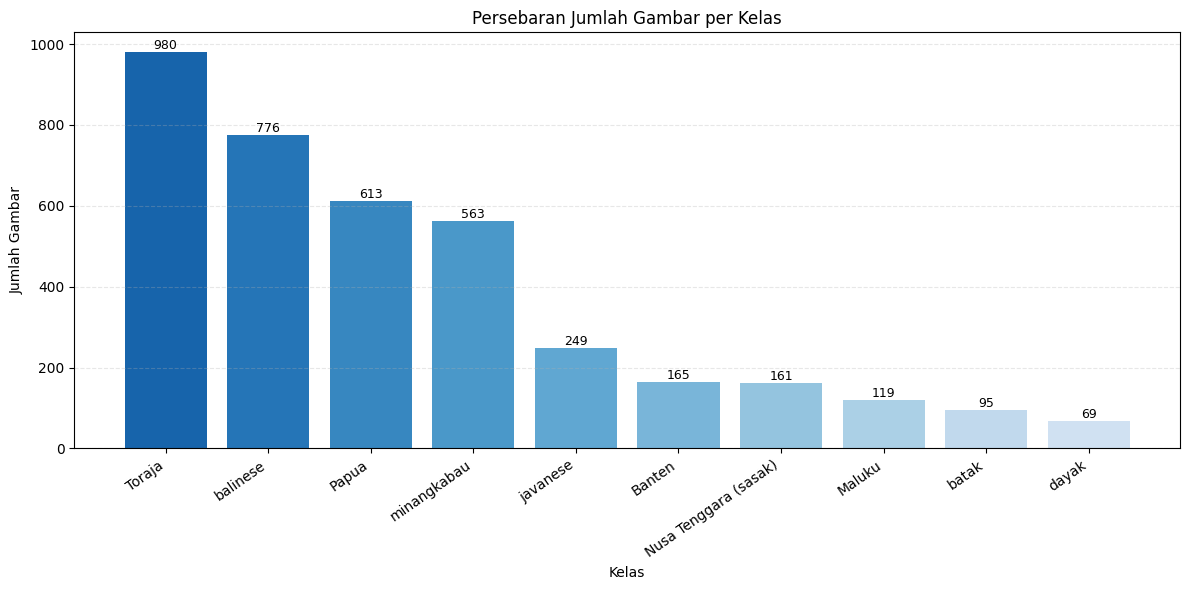

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

base_dir = Path(r"c:\Users\Hakim\Documents\GitHub\Tugas-Besar-AI-untuk-bisnis\model bangunan\Dataset")
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

rows = []
for class_dir in sorted([path for path in base_dir.iterdir() if path.is_dir()]):
    image_count = sum(
        1
        for file_path in class_dir.rglob("*")
        if file_path.is_file() and file_path.suffix.lower() in image_extensions
    )
    rows.append({"kelas": class_dir.name, "jumlah_gambar": image_count})

df = pd.DataFrame(rows).sort_values("jumlah_gambar", ascending=False).reset_index(drop=True)

display(df)

plt.figure(figsize=(12, 6))
bar_colors = plt.cm.Blues_r([0.2 + 0.6 * (index / max(len(df) - 1, 1)) for index in range(len(df))])
ax = plt.bar(df["kelas"], df["jumlah_gambar"], color=bar_colors)

plt.title("Persebaran Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in ax:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()